In [4]:
import mysql.connector
import os
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import mysql.connector
mydb = mysql.connector.connect(
    host = "localhost",
    user = os.getenv("MYSQL_USER"),
    password = os.getenv("MYSQL_PASSWORD"),
    database = 'wingspan'
)
print(mydb)

In [3]:
mycursor = mydb.cursor()

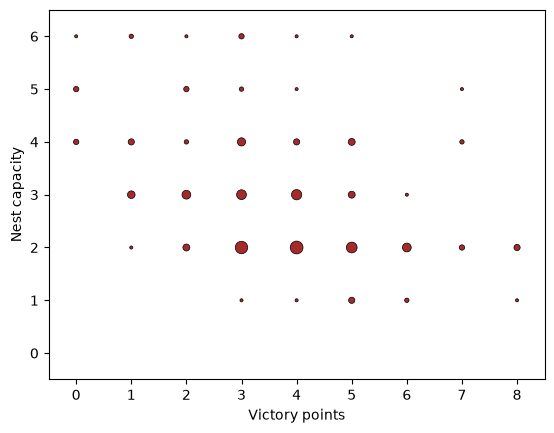

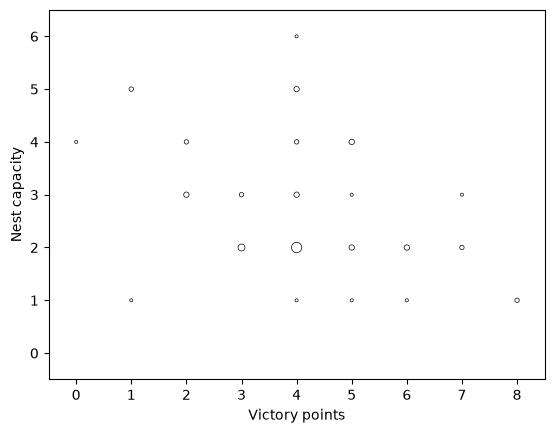

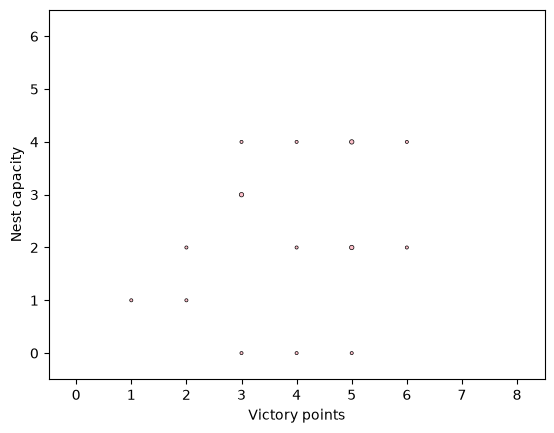

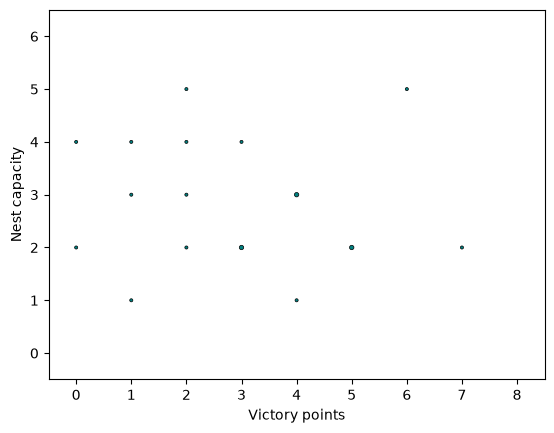

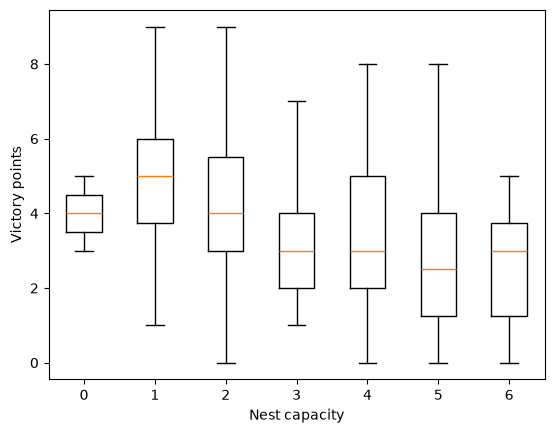

In [27]:
#Plot nest capacity/victory points distribution per bird power color
for color, cmarker in zip(('BR', 'WH', 'PK', 'TL'), ('brown', 'white', 'pink', 'teal')):
    mycursor.execute("SELECT b.victory_points, b.nest_capacity \
                      FROM bird b INNER JOIN power p \
                      ON b.power_id = p.power_id \
                      WHERE p.color = '{}'".format(color))
    data, count = np.unique([row for row in mycursor.fetchall()], axis = 0, return_counts = True)

    plt.figure()
    plt.scatter(data[:, 0], data[:, 1], s = 5*count, linewidths=0.5, edgecolors='black', c = cmarker)
    plt.xlabel("Victory points")
    plt.ylabel("Nest capacity")
    plt.axis(xmin=-0.5, ymin=-0.5, ymax=6.5, xmax=8.5);

#Box plot for victory points distribution as a function of nest capacity
mycursor.execute("SELECT nest_capacity, victory_points FROM bird")
data = np.array([row for row in mycursor.fetchall()])
grouped_data = [data[np.where(data[:, 0] == nest_capacity)[0], 1] for nest_capacity in range(7)]
plt.figure()
plt.boxplot(grouped_data)
plt.ylabel("Victory points")
plt.xlabel("Nest capacity")
plt.xticks(ticks=np.arange(1, 8), labels=np.arange(7))
plt.show();


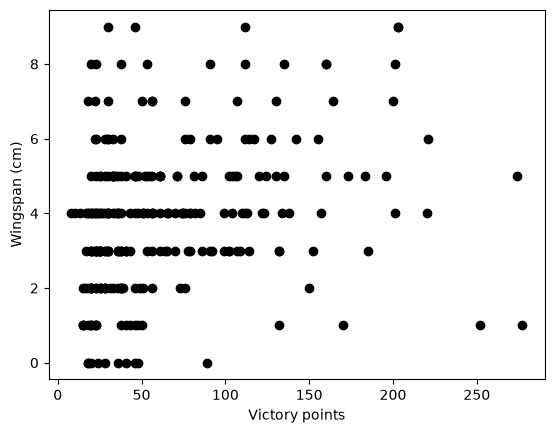

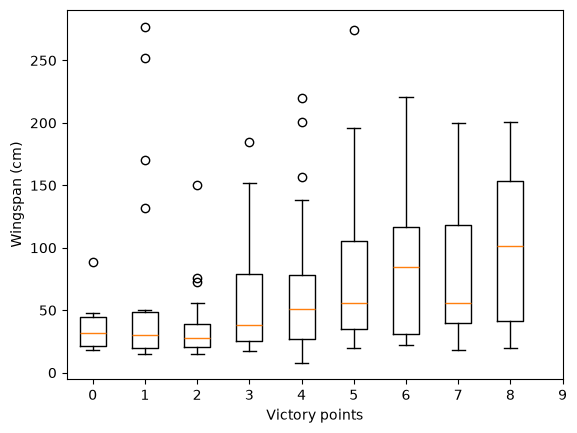

In [20]:
#Inspect how victory points are distributed as a function of wingspan
mycursor.execute("SELECT wingspan, victory_points FROM bird");

data = np.array([row for row in mycursor.fetchall()])

plt.figure()
plt.scatter(data[:, 0], data[:, 1], c = 'black')
plt.ylabel("Wingspan (cm)")
plt.xlabel("Victory points")

grouped_data = [data[np.where(data[:, 1] == victory_points)[0], 0] for victory_points in range(9)]
plt.figure()
plt.boxplot(grouped_data)
plt.ylabel("Wingspan (cm)")
plt.xlabel("Victory points")
plt.xticks(ticks=np.arange(1, 11), labels=np.arange(10))
plt.show();






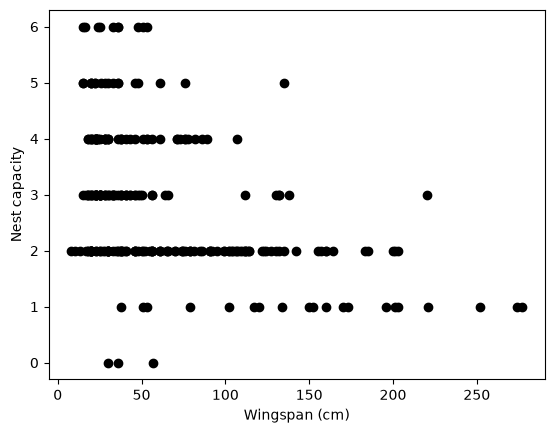

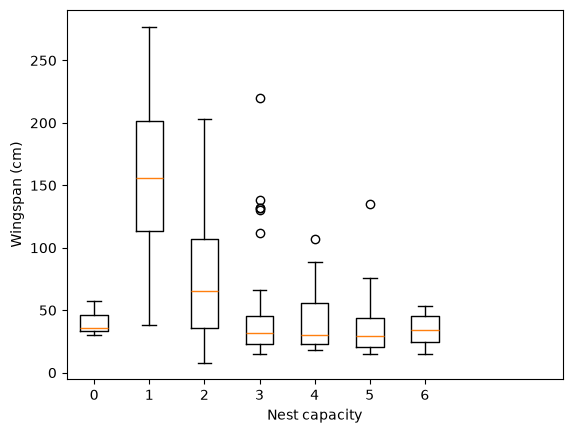

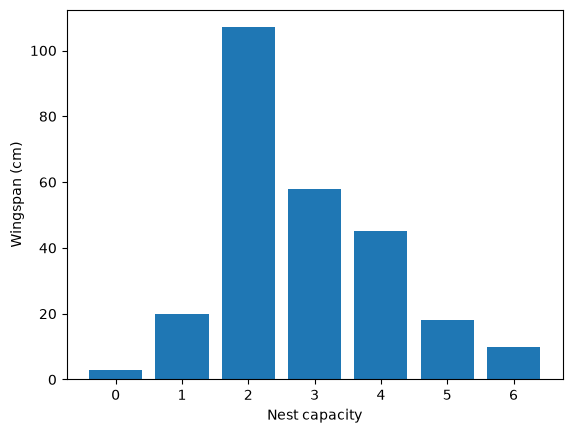

In [4]:
#Inspect how nest capacities are distributed as a function of wingspan
mycursor.execute("SELECT wingspan, nest_capacity FROM bird")

data = np.array([row for row in mycursor.fetchall()])

plt.figure()
plt.scatter(data[:, 0], data[:, 1], c = 'black')
plt.xlabel("Wingspan (cm)")
plt.ylabel("Nest capacity")

grouped_data = [data[np.where(data[:, 1] == victory_points)[0], 0] for victory_points in range(9)]
plt.figure()
plt.boxplot(grouped_data)
plt.ylabel("Wingspan (cm)")
plt.xlabel("Nest capacity")
plt.xticks(ticks=np.arange(1, 8), labels=np.arange(7))
plt.show();

mycursor.execute("SELECT nest_capacity, count(*) FROM bird GROUP BY nest_capacity")
summed_data = np.array([row for row in mycursor.fetchall()])
plt.figure()
plt.bar(summed_data[:, 0], summed_data[:, 1])
plt.ylabel("Wingspan (cm)")
plt.xlabel("Nest capacity");


In [80]:
query = "SELECT victory_points, wingspan, nest_capacity, CASE WHEN food_is_multiple_choice THEN 1 ELSE (worms+grains+berries+fish+rats+wild) END AS food_costs FROM bird"
dataframe = pd.read_sql(query, mydb, dtype=int)

C:\Users\margo\AppData\Local\Temp\ipykernel_10596\2607183491.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataframe = pd.read_sql(query, mydb, dtype=int)


([<matplotlib.axis.XTick at 0x1d029f44e10>,
 [Text(1, 0, '0'), Text(2, 0, '1'), Text(3, 0, '2'), Text(4, 0, '3')])

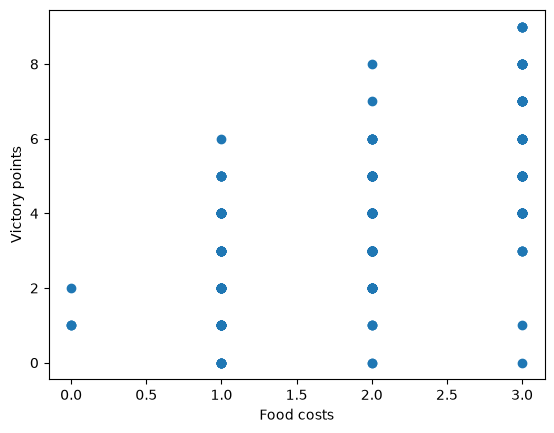

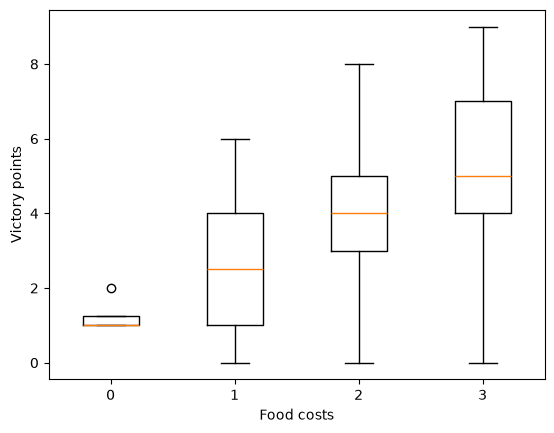

In [25]:
plt.figure()
plt.scatter(dataframe['food_costs'], dataframe['victory_points'])
plt.xlabel("Food costs")
plt.ylabel("Victory points")

grouped_data = [[vp for vp, fc in zip(dataframe['victory_points'], dataframe['food_costs']) if fc==food_costs] for food_costs in range(4)]
plt.figure()
plt.boxplot(grouped_data)
plt.xlabel("Food costs")
plt.ylabel("Victory points")
plt.xticks(np.arange(1, 5), np.arange(4))


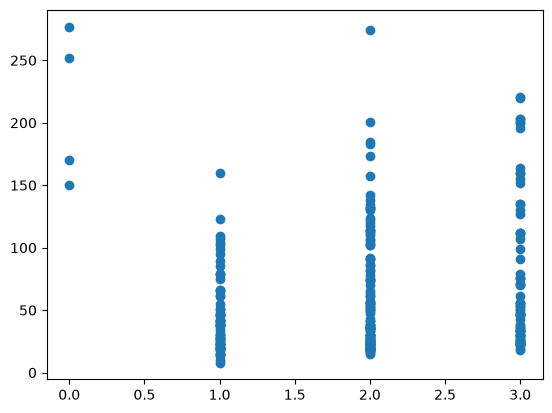

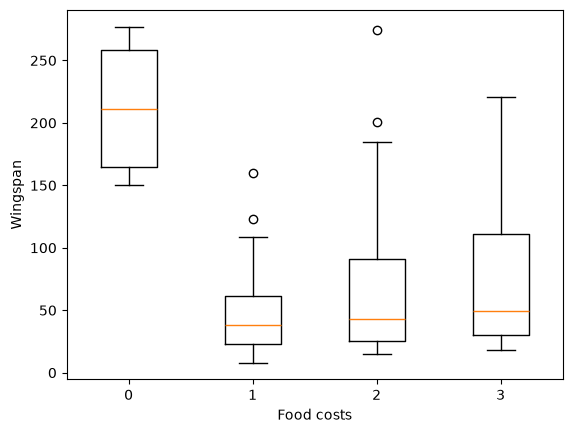

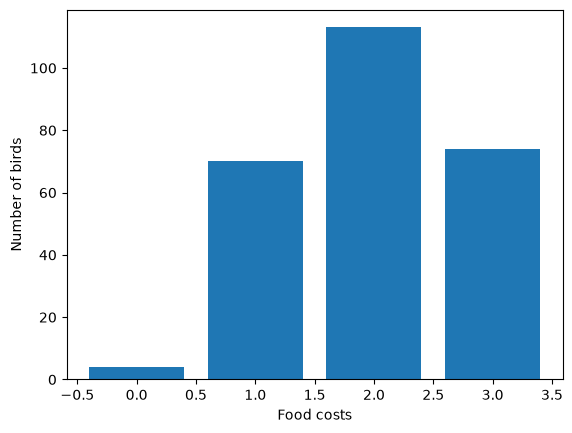

In [82]:
plt.figure()
plt.scatter(dataframe['food_costs'], dataframe['wingspan'])

grouped_data = [[ws for ws, fc in zip(dataframe['wingspan'], dataframe['food_costs']) if fc==food_costs] for food_costs in range(4)]
plt.figure()
plt.boxplot(grouped_data)
plt.xlabel("Food costs")
plt.ylabel("Wingspan")
plt.xticks(np.arange(1, 5), np.arange(4))

plt.figure()
summed_data = [len(group) for group in grouped_data]
plt.bar(np.arange(4), summed_data)
plt.xlabel("Food costs")
plt.ylabel("Number of birds");

([<matplotlib.axis.XTick at 0x1d02b4ad6d0>,
 [Text(1, 0, '0'), Text(2, 0, '1'), Text(3, 0, '2'), Text(4, 0, '3')])

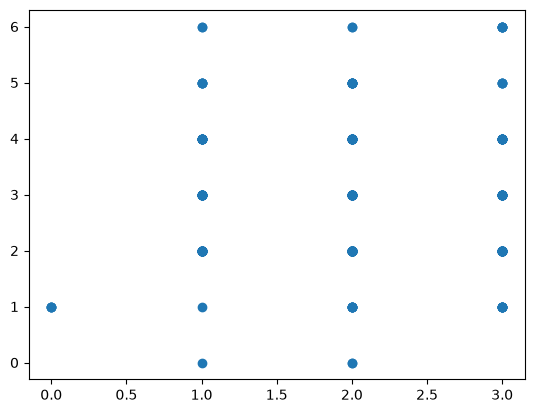

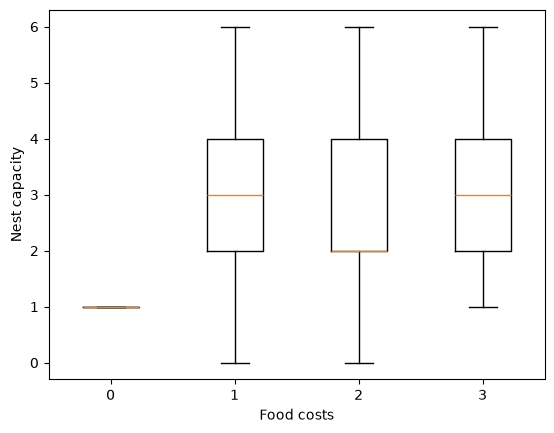

In [29]:
plt.figure()
plt.scatter(dataframe['food_costs'], dataframe['nest_capacity'])

grouped_data = [[nc for nc, fc in zip(dataframe['nest_capacity'], dataframe['food_costs']) if fc==food_costs] for food_costs in range(4)]
plt.figure()
plt.boxplot(grouped_data)
plt.xlabel("Food costs")
plt.ylabel("Nest capacity")
plt.xticks(np.arange(1, 5), np.arange(4))

     wingspan  victory_points  eats_worms  eats_grains  eats_berries  \
0          79               3           0            0             0   
1         106               5           0            0             0   
2          65               4           0            0             0   
3          38               5           1            0             0   
4          61               5           0            0             0   
..        ...             ...         ...          ...           ...   
256        18               4           1            0             0   
257        25               3           1            0             1   
258        38               4           1            1             0   
259        25               2           1            1             0   
260        46               0           0            1             0   

     eats_fish  eats_rats  
0            0          1  
1            0          1  
2            0          1  
3            0         

C:\Users\margo\AppData\Local\Temp\ipykernel_10596\3747435035.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataframe = pd.read_sql(query, mydb)


([<matplotlib.axis.XTick at 0x1d02e4f3250>,
 [Text(1, 0, 'eats_worms'),
  Text(2, 0, 'eats_grains'),
  Text(3, 0, 'eats_berries'),
  Text(4, 0, 'eats_fish'),
  Text(5, 0, 'eats_rats')])

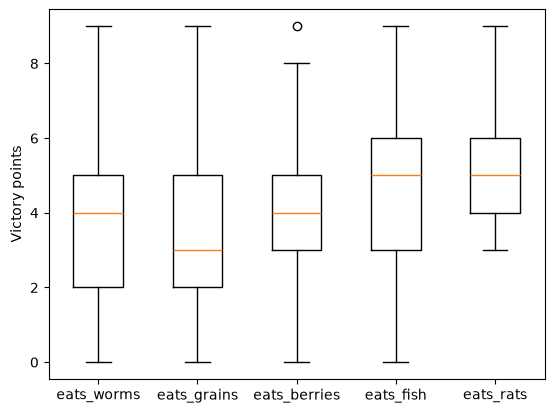

In [42]:
query = "SELECT wingspan, victory_points, (worms > 0) eats_worms, (grains > 0) eats_grains, (berries > 0) eats_berries, (fish > 0) eats_fish, (rats > 0) eats_rats FROM bird"
dataframe = pd.read_sql(query, mydb)
print(dataframe)

diets = dataframe.keys()[2:]
food_vp_data = [dataframe['victory_points'][dataframe[d]==1] for d in diets]

plt.figure()
plt.boxplot(food_vp_data)
plt.ylabel("Victory points")
plt.xticks(np.arange(1, 6), diets)

[  4  70 113  74]
[0.         0.78571429 0.55752212 0.62162162]
[0.5        0.02857143 0.07079646 0.06756757]
[0.25       0.02857143 0.12389381 0.02702703]
[0.25       0.15714286 0.2300885  0.22972973]
[0.         0.         0.01769912 0.05405405]


C:\Users\margo\AppData\Local\Temp\ipykernel_10596\3320861003.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataframe = pd.read_sql(query, mydb)


Text(0, 0.5, 'Victory points')

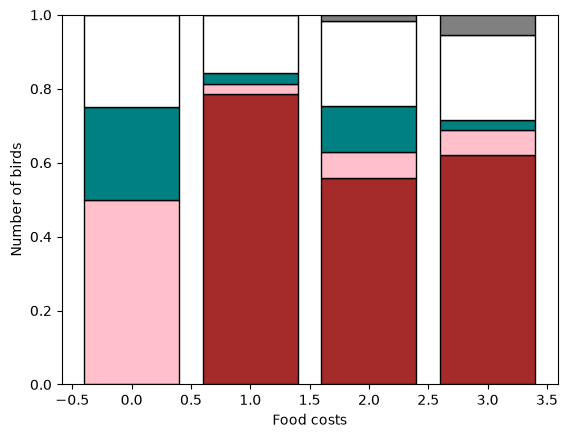

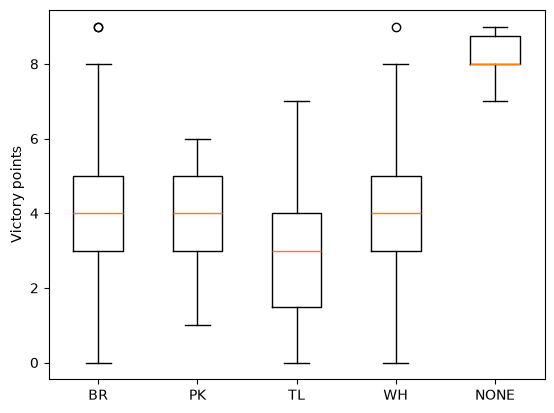

In [77]:
query = "SELECT victory_points, CAST(CASE WHEN food_is_multiple_choice THEN 1 ELSE (worms+grains+berries+fish+rats+wild) END AS UNSIGNED INTEGER) AS food_costs, \
CASE WHEN b.power_id IS NULL THEN 'NONE' ELSE p.color END AS power_color FROM bird b LEFT JOIN power p ON b.power_id = p.power_id"
dataframe = pd.read_sql(query, mydb)

plt.figure()
plt.xlabel("Food costs")
plt.ylabel("Number of birds")
bottom = np.array([0, 0, 0, 0], dtype=float)
total_birds_per_food_cost = np.array([sum((dataframe['food_costs']==fc)) for fc in range(4)])
print(total_birds_per_food_cost)
power_colors = ['BR', 'PK', 'TL', 'WH', 'NONE']
for power_color, bar_color in zip(power_colors, ['brown', 'pink', 'teal', 'white', 'gray']):
    bird_counts_per_food_cost = np.array([sum((dataframe['power_color']==power_color)*(dataframe['food_costs']==fc)) for fc in range(4)])/total_birds_per_food_cost
    print(bird_counts_per_food_cost)
    plt.bar(np.arange(4), bird_counts_per_food_cost, color=bar_color, edgecolor='black', bottom=bottom)
    bottom += np.array(bird_counts_per_food_cost)

vp_per_power_color = [dataframe['victory_points'][dataframe['power_color'] == pc] for pc in power_colors]
plt.figure()
plt.boxplot(vp_per_power_color, tick_labels=power_colors)
plt.ylabel("Victory points")